# EJERCICIOS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from keras.applications import ResNet101V2, MobileNetV2
import os
import tensorflow_hub as hub
from keras.utils import to_categorical, img_to_array, load_img
from keras import Sequential
from keras.layers import Input, Dense, Flatten, Concatenate, MaxPool2D, Dropout, MaxPooling2D,Conv2D,GlobalAveragePooling2D
from functools import partial
from keras.preprocessing import image, image_dataset_from_directory
import matplotlib as mpl
import PIL.Image

2025-02-24 18:24:12.049948: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-24 18:24:12.111254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-24 18:24:12.126188: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-24 18:24:12.130265: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-24 18:24:12.186440: I tensorflow/core/platform/cpu_feature_guar

In [2]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
len(tf.config.list_physical_devices('GPU'))

I0000 00:00:1739803980.124494   13735 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739803980.150279   13735 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739803980.150428   13735 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


1

## EJERCICIO 1

Crea tu propia CNN desde el principio e intenta conseguir la mayor exactitud posible con MNIST (por ejemplo 99% en el conjunto de prueba).

En vez de crear un conjunto de validación en el fit indica que porcentaje (10%) vas a usar para el conjunto de validación (validation_split)

Por ejemplo:
* 2 capas convolucionales (32 filtros)
* 1 capa maxpool
* 2 capas convolucionales (64 filtros)
* 1 capa maxpool
* 1 capa flatten
* 1 capa dropout
* 1 capa densa oculta
* 1 capa dropout
* 1 capa densa de salida

Usá como función de pérdida categorical_crossentropy.

Ten en cuenta que:
* sparse_categorical_crossentropy: se usa cuando las etiquetas de las clases están representadas como enteros (codificación entera), por ejemplo: 0, 1, 2, 3, ... para n clasess
* categorical_crossentropy: se usa cuando las etiquetas están representadas en formato one-hot encoded.

Tal y com tenemos los datos podemos usar directamente sparse_categorical_crossentropy, para poder aplicar categorical_crossentropy hay que hacer una transformación en y (to_categorical).

Haz una predicción y muestra la imagen con la etiqueta real y la predicha.

In [17]:
#Cargar datos
datos = tf.keras.datasets.mnist.load_data()

In [18]:
#Dividir datos
(X_train, y_train), (X_test, y_test) = datos

In [19]:
X_train.shape

(60000, 28, 28)

In [20]:
X_test.shape

(10000, 28, 28)

In [21]:
#Normalizar
X_train, X_test = X_train / 255.0, X_test / 255.0 

In [22]:
# Redimensionar para CNN
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)) 
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)) 

In [23]:
X_train.shape

(60000, 28, 28, 1)

In [24]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [25]:
#Crear modelo
tf.random.set_seed(42)
model = tf.keras.Sequential([
    Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding="same"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding="same"),
    Conv2D(64, (3, 3), activation='relu', padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(units=10, activation="softmax")
])


In [26]:
#Compilar modelo
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [27]:
#Entrenar modelo
history = model.fit(X_train, y_train, epochs=20, validation_split=0.1)

Epoch 1/20
1688/1688 [==============================] - 49s 29ms/step - loss: 0.2195 - accuracy: 0.9314 - val_loss: 0.0457 - val_accuracy: 0.9868
Epoch 2/20
1688/1688 [==============================] - 48s 28ms/step - loss: 0.0885 - accuracy: 0.9748 - val_loss: 0.0337 - val_accuracy: 0.9913
Epoch 3/20
1688/1688 [==============================] - 48s 29ms/step - loss: 0.0678 - accuracy: 0.9800 - val_loss: 0.0300 - val_accuracy: 0.9917
Epoch 4/20
1688/1688 [==============================] - 47s 28ms/step - loss: 0.0555 - accuracy: 0.9836 - val_loss: 0.0293 - val_accuracy: 0.9920
Epoch 5/20
1688/1688 [==============================] - 48s 28ms/step - loss: 0.0486 - accuracy: 0.9858 - val_loss: 0.0254 - val_accuracy: 0.9933
Epoch 6/20
1688/1688 [==============================] - 48s 28ms/step - loss: 0.0430 - accuracy: 0.9876 - val_loss: 0.0283 - val_accuracy: 0.9925
Epoch 7/20
1688/1688 [==============================] - 48s 28ms/step - loss: 0.0376 - accuracy: 0.9888 - val_loss: 0.0299 -

In [28]:
#Evaluar modelo
score = model.evaluate(X_test, y_test)

313/313 [==============================] - 4s 13ms/step - loss: 0.0258 - accuracy: 0.9934


1/1 [==============================] - 0s 17ms/step


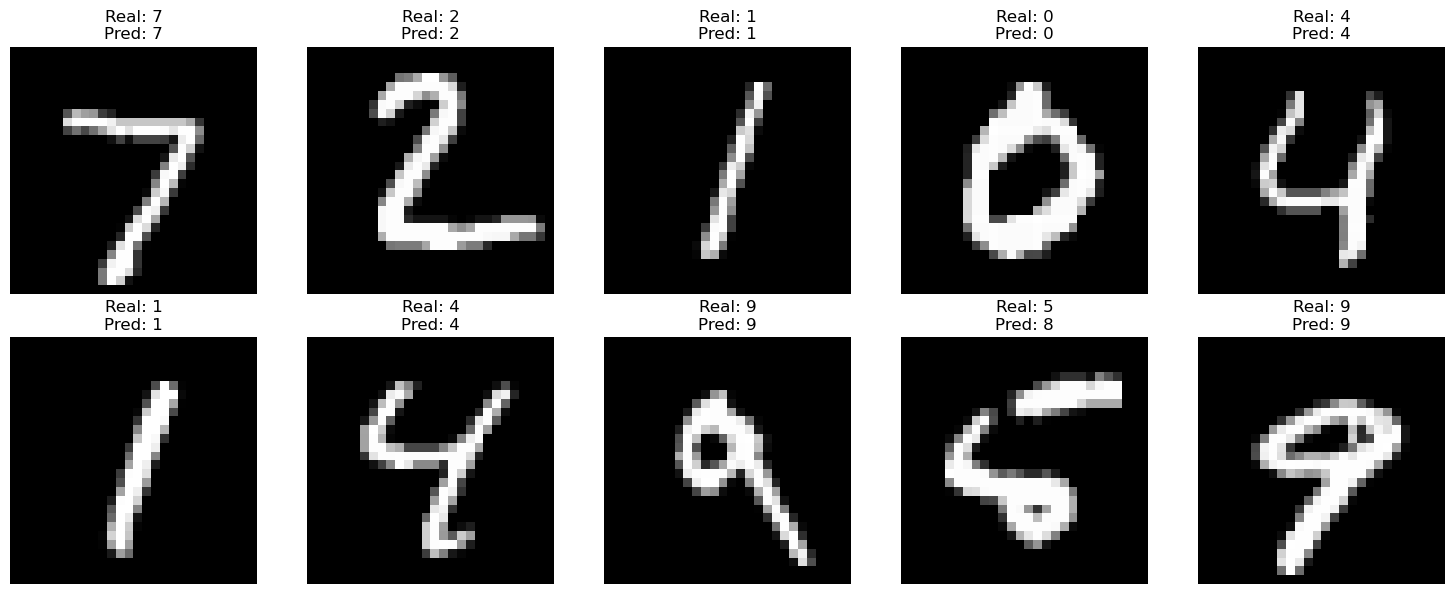

In [32]:
#Predicciones
X_new = X_test[:10]
Y_new = y_test[:10] 
y_pred = model.predict(X_new)
y_pred = np.argmax(y_pred, axis=1)
y_real = np.argmax(Y_new, axis=1)

# Visualizar las imágenes junto con las etiquetas reales y las predicciones
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_new[i].squeeze(), cmap='gray')  
    plt.title(f"Real: {y_real[i]}\nPred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## EJERCICIO 2

Haz unas fotos con tu movil (a objetos) y usando alguno de los modelos que existen (por ejemplo ResNet101V2). Tendrás de adecuar el tamaño de las fotos antes de intentar predecir que es lo que has fotografiado.

Tendrás que investigar como añadir cargar tus images, un buen sitio por donde empezar es por la documentación de Keras para ResNEt101V2.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicciones para la imagen: images/pera.jpeg
1: lemon (94.27%)
2: Granny_Smith (2.73%)
3: butternut_squash (2.00%)


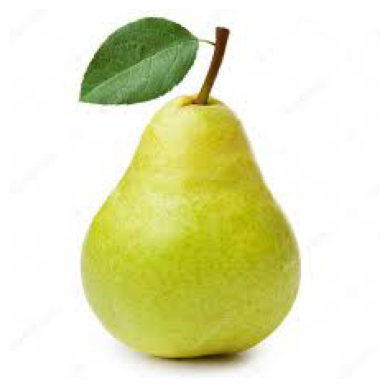

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Predicciones para la imagen: images/tortuga.jpeg
1: terrapin (99.94%)
2: mud_turtle (0.05%)
3: box_turtle (0.01%)


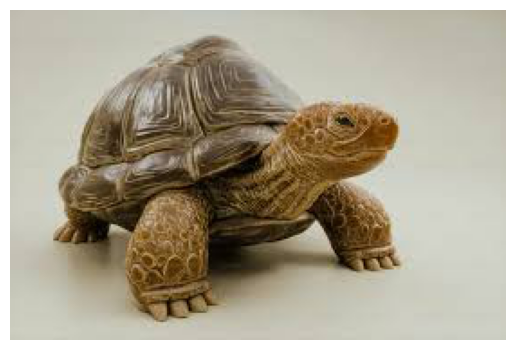

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Predicciones para la imagen: images/velero.jpeg
1: schooner (79.87%)
2: yawl (20.09%)
3: trimaran (0.02%)


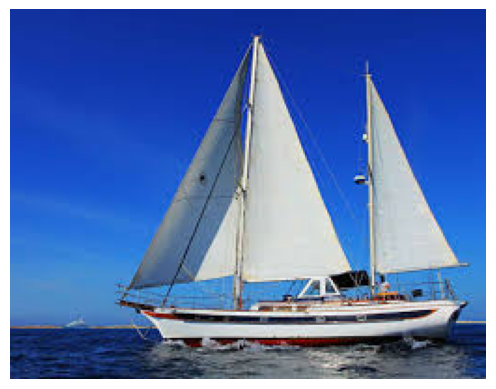

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Predicciones para la imagen: images/balon.jpeg
1: basketball (100.00%)
2: monarch (0.00%)
3: croquet_ball (0.00%)


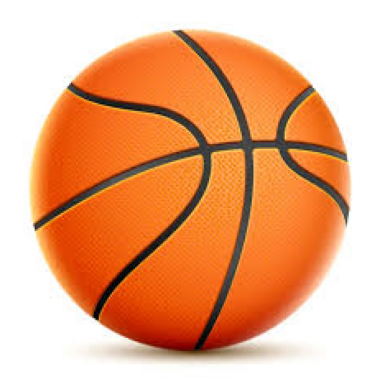

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Predicciones para la imagen: images/libro.jpeg
1: library (49.36%)
2: bookcase (38.02%)
3: bookshop (12.60%)


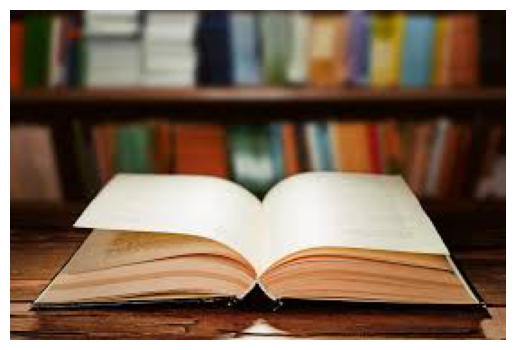

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Predicciones para la imagen: images/piano.jpeg
1: grand_piano (99.98%)
2: upright (0.02%)
3: organ (0.00%)


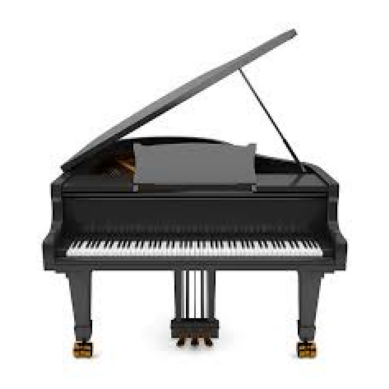

In [7]:
# Cargar el modelo ResNet101V2 preentrenado
model = tf.keras.applications.ResNet101V2(weights='imagenet')

# Función para preprocesar la imagen
def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))  
    img_array = image.img_to_array(img)
    # Expandir las dimensiones para que sea (batch_size, height, width, channels)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet_v2.preprocess_input(img_array)
    return img_array

# Función para hacer predicción
def make_prediction(image_paths):
    for image_path in image_paths:
        img_array = preprocess_image(image_path)
        predictions = model.predict(img_array)
        
        # Decodificar las predicciones 
        decoded_predictions = tf.keras.applications.resnet_v2.decode_predictions(predictions, top=3)[0]
        
        print(f"\nPredicciones para la imagen: {image_path}")
        for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
            print(f"{i+1}: {label} ({score*100:.2f}%)")
        
        # Mostrar la imagen
        img = image.load_img(image_path)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

# Lista de rutas de imágenes
image_paths = [
    'images/pera.jpeg',
    'images/tortuga.jpeg',
    'images/velero.jpeg',
    'images/balon.jpeg',
    'images/libro.jpeg',
    'images/piano.jpeg'
]

# Hacer predicciones para todas las imágenes
make_prediction(image_paths)

## EJERCICIO 3

El dataset food101 es un conjunto de datos consta de 101 categorías de alimentos, con 101000 imágenes. Para cada clase, se proporcionan 250 imágenes de prueba revisadas manualmente, así como 750 imágenes de entrenamiento. A propósito, las imágenes de entrenamiento no se limpiaron y, por lo tanto, aún contienen cierta cantidad de ruido. Esto viene principalmente en forma de colores intensos y, a veces, etiquetas incorrectas. Todas las imágenes se redimensionaron para tener una longitud lateral máxima de 512 píxeles.
* Carga el conjunto de imagenes: entrenamiento, validación (coge la mitad de los datos de prueba) y prueba (coge la otra mitad de los datos de prueba)
* Explora los datos: dimensiones, número de elementos, dibuja algunas imagenes con sus etiquetas...
* Prepara los datos: añade más elementos al conjunto de entrenamiento (rotando, trasladando... las imagenes acutales), cambia el tamaño para que sea adecuado para el modelo, normaliza...
* Entrena un modelo para estos datos usando algunas de las redes ya existentes (por ejemplo: MobileNetV2): coge todo menos la última capa y añade una capa globalaveragepooling y la capa dense de salida. En este caso utiliza como función de pérdida sparse_categorical_crossentropy
* Busca una imagen de comida en Internet y haz una predicción

Por defecto tensorflow busca y descarga los dato en:
* Linux/Mac: ~/tensorflow_datasets/
* Windows: C:\Users\<usuario>\tensorflow_datasets\

Los datos puedes copiarlo de mi disco duro o descarlos, pero son 5.12GB

In [ ]:
#El tfds.load() me está dando problemas, así que cargo las imágenes y los divido manualmente

In [ ]:
#dataset, info = tfds.load('food101',  with_info=True, as_supervised=True)
#print(info)
#dataset_size = info.splits["train"].num_examples
#class_names = info.features["label"].names
#n_classes = info.features["label"].num_classes

#train_set_raw, valid_set_raw, test_set_raw = tfds.load(
#    "food101",
#    split=["train[:80%]", "train[80%:90%]", "train[90%:]"], 
#    as_supervised=True 
#)

In [ ]:
# Ruta donde están todas las imágenes
images_dir = "C:/Users/Jon/Desktop/food-101/images" 

# Cargar todas las imágenes
dataset = image_dataset_from_directory(
    images_dir,
    batch_size=32,         
    label_mode='int',       
    shuffle=True           
)

Found 101000 files belonging to 101 classes.


In [6]:
# Obtener tamaño total del dataset
dataset_size = len(dataset)

# Dividir el dataset en 80% entrenamiento, 10% validación y 10% prueba
train_size = int(0.8 * dataset_size)
valid_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - valid_size  # Lo que quede para test

# Aplicar la división
train_set_raw = dataset.take(train_size)
valid_set_raw = dataset.skip(train_size).take(valid_size)
test_set_raw = dataset.skip(train_size + valid_size)

# Imprimir tamaños para verificación
print(f"Tamaño del dataset: {dataset_size}")
print(f"Train: {len(train_set_raw)} - Valid: {len(valid_set_raw)} - Test: {len(test_set_raw)}")

Tamaño del dataset: 3157
Train: 2525 - Valid: 315 - Test: 317


In [8]:
class_names = dataset.class_names

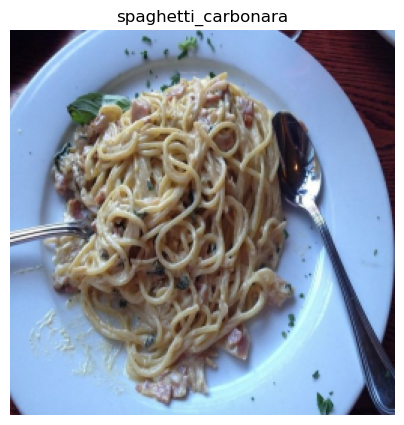

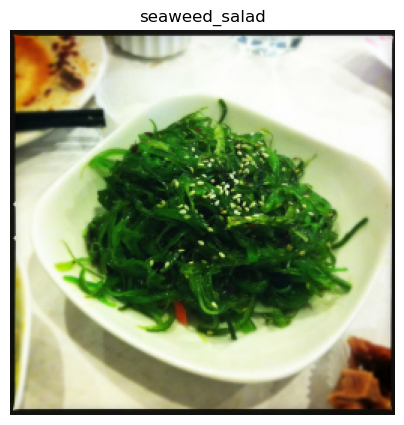

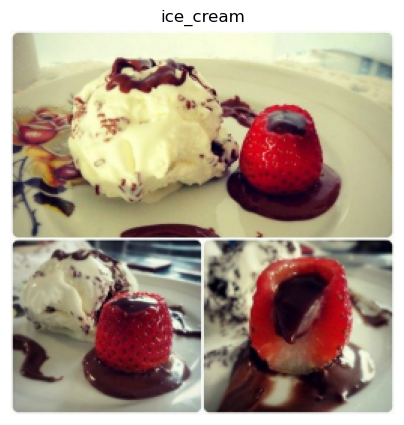

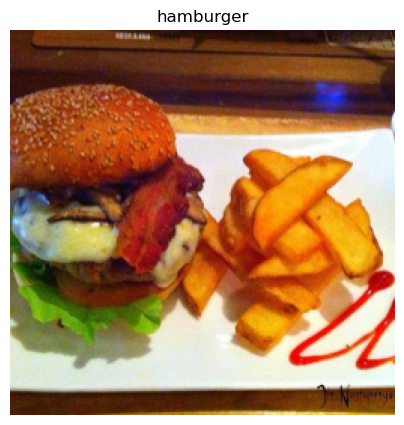

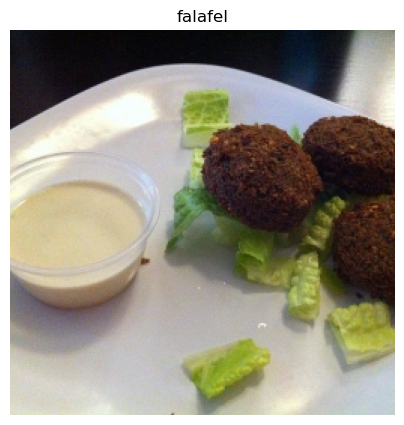

In [9]:
for image_batch, label_batch in dataset.take(1):  # Tomamos el primer lote
    for i in range(5):  
        image = image_batch[i].numpy() 
        label = label_batch[i].numpy()  
        
        # Mostrar la imagen
        plt.figure(figsize=(5, 5))
        plt.imshow(image.astype("uint8"))  
        plt.title(class_names[label])  
        plt.axis('off')  
        plt.show()

In [11]:
for image, label in train_set_raw.take(1): 
    print("Forma de la imagen:", image.shape)

Forma de la imagen: (32, 256, 256, 3)


In [13]:
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  
    return image, label


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

# Aplicar aumentación de datos solo al conjunto de entrenamiento
def augment_image(image, label):
    image = data_augmentation(image) 
    return image, label

train_set_prep = train_set_raw.map(preprocess_image)
train_set_aug = train_set_raw.map(augment_image).map(preprocess_image)

# Concatenamos los datos modificados y los originales
train_set = train_set_prep.concatenate(train_set_aug).map(preprocess_image).prefetch(tf.data.AUTOTUNE)
valid_set = valid_set_raw.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
test_set = test_set_raw.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

In [15]:
# Cargar el modelo MobileNetV2 preentrenado (sin la última capa)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

# Crear el modelo
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(101, activation='softmax')  # 101 clases para las categorías de alimentos
])

# Compilar el modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_1 (Dense)             (None, 101)               129381    
                                                                 
Total params: 2,387,365
Trainable params: 129,381
Non-trainable params: 2,257,984
_________________________________________________________________


In [17]:
# Entrenar el modelo
history = model.fit(train_set, validation_data=valid_set, epochs=2)

Epoch 1/2
5050/5050 [==============================] - 2529s 501ms/step - loss: 4.5499 - accuracy: 0.0302 - val_loss: 14.0860 - val_accuracy: 0.0126
Epoch 2/2
5050/5050 [==============================] - 2324s 460ms/step - loss: 4.4069 - accuracy: 0.0456 - val_loss: 19.3491 - val_accuracy: 0.0146


In [ ]:
total_layers = len(base_model.layers) 
print(total_layers)

154


In [31]:
# Utilizando zip para iterar por grupos de índices
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132), range(132, 154)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end=" ")
    print()

  0: input_2                 33: block_3_depthwise_relu  66: block_7_depthwise       99: block_11_expand_BN     132: block_14_project_BN    
  1: Conv1                   34: block_3_project         67: block_7_depthwise_BN   100: block_11_expand_relu   133: block_14_add           
  2: bn_Conv1                35: block_3_project_BN      68: block_7_depthwise_relu 101: block_11_depthwise     134: block_15_expand        
  3: Conv1_relu              36: block_4_expand          69: block_7_project        102: block_11_depthwise_BN  135: block_15_expand_BN     
  4: expanded_conv_depthwise  37: block_4_expand_BN       70: block_7_project_BN     103: block_11_depthwise_relu 136: block_15_expand_relu   
  5: expanded_conv_depthwise_BN  38: block_4_expand_relu     71: block_7_add            104: block_11_project       137: block_15_depthwise     
  6: expanded_conv_depthwise_relu  39: block_4_depthwise       72: block_8_expand         105: block_11_project_BN    138: block_15_depthwise_BN  
 

In [37]:
# Descongelar las últimas 47 capas 
for idx in range(len(base_model.layers) - 47, len(base_model.layers)):
    base_model.layers[idx].trainable = True

In [33]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [38]:
history_2 = model.fit(train_set, validation_data=valid_set, epochs=1)

5050/5050 [==============================] - 2336s 462ms/step - loss: 5.3776 - accuracy: 0.0343 - val_loss: 7.5567 - val_accuracy: 0.0127


1/1 [==============================] - 1s 620ms/step


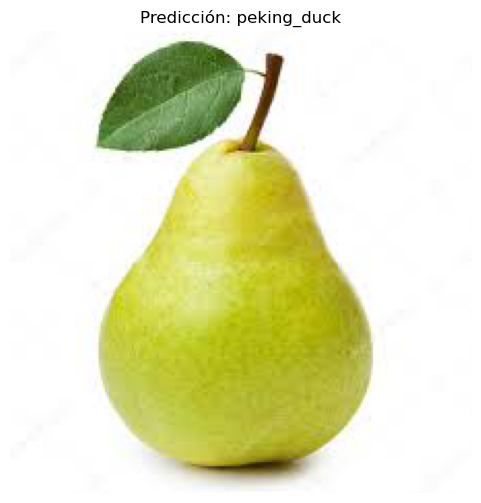

In [ ]:
# Cargar y preprocesar la imagen antes de predecir
img_path = 'pera.jpeg'
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224)) 
img_array = tf.keras.preprocessing.image.img_to_array(img) 
img_tensor = tf.convert_to_tensor(img_array) 

# Pasamos el tensor a la función preprocess_image para aplicar redimensionamiento y normalización
img_tensor, _ = preprocess_image(img_tensor, label=0)  

# Añadir dimensión de batch
img_tensor = tf.expand_dims(img_tensor, axis=0)

# Realizar la predicción
pred = model.predict(img_tensor) 
pred_class = np.argmax(pred)  

# Mostrar la imagen y la etiqueta predicha
plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.axis('off') 
plt.title(f"Predicción: {class_names[pred_class]}") 
plt.show()

## EJERCICIO 4

Repite el ejercicio pero para otros datos (tienes conjuntos de datos en https://www.tensorflow.org/datasets/catalog/overview?hl=es-419 en el apartado image classificación, por ejemplo puedes usar stanford_dogs) y utilizando otra de las redes conocidas que no se haya utilizado todavía.
Para cargar los datos en este caso vas a descargar las imagnes a tu ordenador y cargarlos desde ahi (descargar la carpeta al ordenador y luego cargarlo desde la carpeta con python (mage_dataset_from_director)):

* Carga el conjunto de imagenes (entrenamiento, validación y pruebas)
* Explora los datos: dimensiones, número de elementos, dibuja algunas imagenes con sus etiquetas...
* Prepara los datos: añadir más elementos al conjunto de entrenamiento (rotando, trasladando... las imagenes acutales), cambiar el tamaño para que sea adecuado para el modelo, normalizar...
* Entrena un modelo para estos datos usando algunas de las redes ya existentes (por ejemplo: MobileNetV2)
* Busa una imagen en Internet y haz una predicción

In [ ]:
# Ruta donde están todas las imágenes
images_dir = "C:/Users/Jon/Desktop/images" 

# Cargar todas las imágenes
dataset = image_dataset_from_directory(
    images_dir,
    batch_size=32,         
    label_mode='int',       
    shuffle=True           
)

# Verificar las dimensiones del dataset cargado
print(f"Tamaño del dataset cargado: {len(dataset)}")

# Calcular las cantidades para los conjuntos
train_size = int(20580 * 0.8)  # 80% para entrenamiento
val_size = int(20580 * 0.1)  # 10% para validación
test_size = 20580 - train_size - val_size  # El resto será para el conjunto de prueba

# Crear los conjuntos
train_dataset = dataset.take(train_size // 32)  # Dividir para que el tamaño sea en batches
val_dataset = dataset.skip(train_size // 32).take(val_size // 32)
test_dataset = dataset.skip(train_size // 32 + val_size // 32)

# Verificar tamaños
print(f"Tamaño del conjunto de entrenamiento: {len(train_dataset)} batches")
print(f"Tamaño del conjunto de validación: {len(val_dataset)} batches")
print(f"Tamaño del conjunto de prueba: {len(test_dataset)} batches")


Found 20580 files belonging to 120 classes.
Tamaño del dataset cargado: 644
Tamaño del conjunto de entrenamiento: 514 batches
Tamaño del conjunto de validación: 64 batches
Tamaño del conjunto de prueba: 66 batches


In [48]:
class_names = dataset.class_names

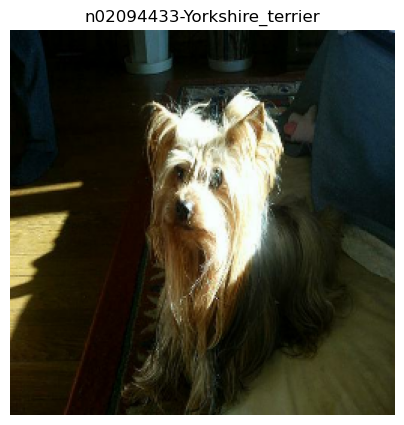

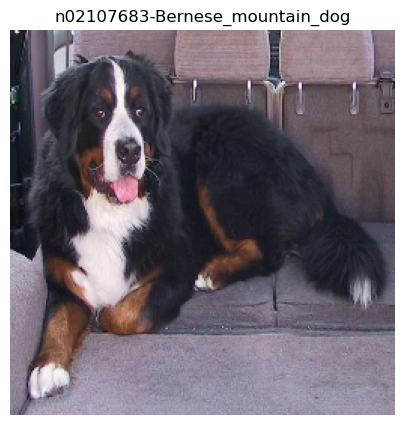

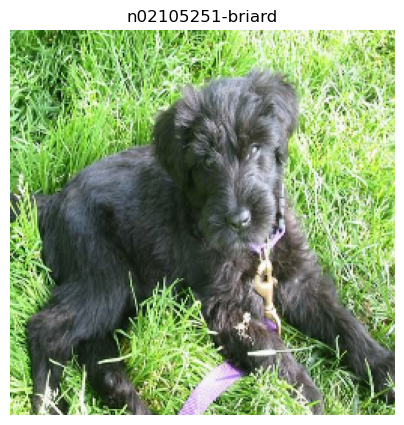

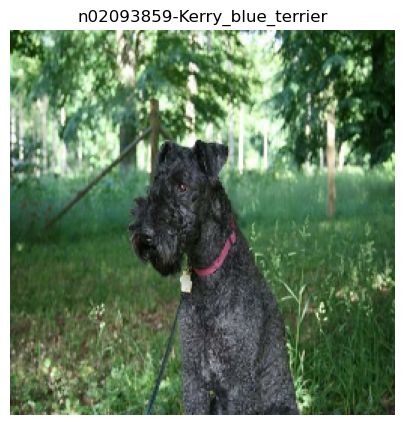

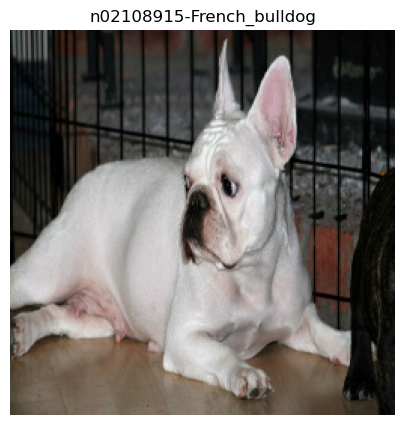

In [49]:
for image_batch, label_batch in dataset.take(1):  # Tomamos el primer lote
    for i in range(5):  
        image = image_batch[i].numpy() 
        label = label_batch[i].numpy()  
        
        # Mostrar la imagen
        plt.figure(figsize=(5, 5))
        plt.imshow(image.astype("uint8"))  
        plt.title(class_names[label])  
        plt.axis('off')  
        plt.show()

In [50]:
for image, label in train_dataset.take(1): 
    print("Forma de la imagen:", image.shape)

Forma de la imagen: (32, 256, 256, 3)


In [51]:
#Redimensionar imágenes y normalizar
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  
    return image, label

In [52]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

# Aplicar aumentación de datos solo al conjunto de entrenamiento
def augment_image(image, label):
    image = data_augmentation(image) 
    return image, label

train_dataset_prep = train_dataset.map(preprocess_image)
train_dataset_aug = train_dataset.map(augment_image).map(preprocess_image)

train_dataset = train_dataset_prep.concatenate(train_dataset_aug).map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

In [53]:
# Cargar el modelo MobileNetV2 preentrenado (sin la última capa)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Congelar las capas base

# Crear el modelo
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(120, activation='softmax') #120 clases de perro
])

# Compilar el modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 120)               153720    
                                                                 
Total params: 2,411,704
Trainable params: 153,720
Non-trainable params: 2,257,984
_________________________________________________________________


In [54]:
# Entrenar el modelo
history3 = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

Epoch 1/5
1028/1028 [==============================] - 468s 451ms/step - loss: 4.8684 - accuracy: 0.0147 - val_loss: 9.2104 - val_accuracy: 0.0103
Epoch 2/5
1028/1028 [==============================] - 461s 448ms/step - loss: 4.7437 - accuracy: 0.0257 - val_loss: 14.6074 - val_accuracy: 0.0054
Epoch 3/5
1028/1028 [==============================] - 463s 450ms/step - loss: 4.6627 - accuracy: 0.0330 - val_loss: 20.3623 - val_accuracy: 0.0039
Epoch 4/5
1028/1028 [==============================] - 465s 452ms/step - loss: 4.6049 - accuracy: 0.0404 - val_loss: 25.5848 - val_accuracy: 0.0068
Epoch 5/5
1028/1028 [==============================] - 468s 455ms/step - loss: 4.5544 - accuracy: 0.0450 - val_loss: 29.9292 - val_accuracy: 0.0044


In [55]:
total_layers = len(base_model.layers) 
print(total_layers)

154


In [56]:
# Utilizando zip para iterar por grupos de índices
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132), range(132, 154)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end=" ")
    print()

  0: input_3                 33: block_3_depthwise_relu  66: block_7_depthwise       99: block_11_expand_BN     132: block_14_project_BN    
  1: Conv1                   34: block_3_project         67: block_7_depthwise_BN   100: block_11_expand_relu   133: block_14_add           
  2: bn_Conv1                35: block_3_project_BN      68: block_7_depthwise_relu 101: block_11_depthwise     134: block_15_expand        
  3: Conv1_relu              36: block_4_expand          69: block_7_project        102: block_11_depthwise_BN  135: block_15_expand_BN     
  4: expanded_conv_depthwise  37: block_4_expand_BN       70: block_7_project_BN     103: block_11_depthwise_relu 136: block_15_expand_relu   
  5: expanded_conv_depthwise_BN  38: block_4_expand_relu     71: block_7_add            104: block_11_project       137: block_15_depthwise     
  6: expanded_conv_depthwise_relu  39: block_4_depthwise       72: block_8_expand         105: block_11_project_BN    138: block_15_depthwise_BN  
 

In [57]:
# Descongelar las últimas 73 capas 
for idx in range(len(base_model.layers) - 73, len(base_model.layers)):
    base_model.layers[idx].trainable = True

In [58]:
#Compilar de nuevo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [60]:
#Reentrenar el modelo
history_4 = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

Epoch 1/5
1028/1028 [==============================] - 468s 453ms/step - loss: 9.2310 - accuracy: 0.0174 - val_loss: 10.5973 - val_accuracy: 0.0088
Epoch 2/5
1028/1028 [==============================] - 470s 457ms/step - loss: 6.2731 - accuracy: 0.0414 - val_loss: 10.8836 - val_accuracy: 0.0083
Epoch 3/5
1028/1028 [==============================] - 465s 452ms/step - loss: 5.3057 - accuracy: 0.0740 - val_loss: 10.8324 - val_accuracy: 0.0078
Epoch 4/5
1028/1028 [==============================] - 469s 456ms/step - loss: 4.6869 - accuracy: 0.1054 - val_loss: 10.6153 - val_accuracy: 0.0063
Epoch 5/5
1028/1028 [==============================] - 466s 453ms/step - loss: 4.2468 - accuracy: 0.1380 - val_loss: 10.5456 - val_accuracy: 0.0083


1/1 [==============================] - 1s 607ms/step


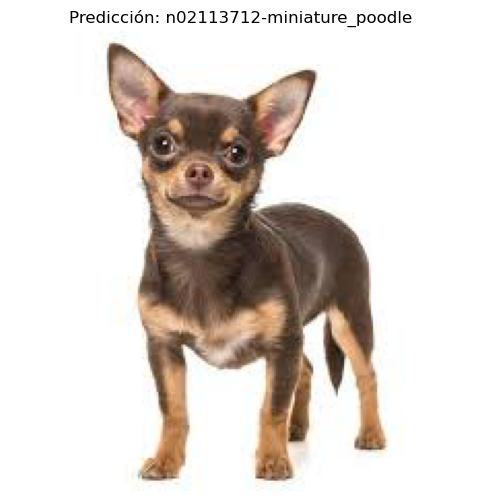

In [61]:
# Cargar y procesar la imagen
img_path = 'chihuahua.jpeg'  
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224)) 
img_array = tf.keras.preprocessing.image.img_to_array(img) 
img_tensor = tf.convert_to_tensor(img_array)  

# Pasamos el tensor a la función preprocess_image para aplicar redimensionamiento y normalización
img_tensor, _ = preprocess_image(img_tensor, label=0) 

# Añadir dimensión de batch
img_tensor = tf.expand_dims(img_tensor, axis=0)

# Realizar la predicción
pred = model.predict(img_tensor) 
pred_class = np.argmax(pred)  

# Mostrar la imagen y la etiqueta predicha
plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.axis('off') 
plt.title(f"Predicción: {class_names[pred_class]}") 

plt.show()

## EJERCICIO 5

Sigue el tutorial de TensorFlow Style Transfer (https://homl.info/styletuto) hasta definir representaciones de contenido y estilo (hay que hacer sólo los primeros puntos, hasta el punto  Transferencia de estilo rápido usando TF-Hub (incluido)).

Haz algo parecido no igual (por lo menos cambia de imagenes).

Además tienes que poner comentarios para explicar con tus palabras lo que estas haciendo.

Realmente lo que esta haciendo es aplicar una capas convolucionales a una imagen, donde los filtros se han sacado de otra imagen.

In [4]:
# Configuración de parámetros de visualización y TensorFlow Hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

In [5]:
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

In [6]:
# Función para convertir un tensor a imagen
def tensor_to_image(tensor):
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

In [13]:
#Ruta de la imagenes de contenido y estilo
content_path = 'images/paisaje.jpeg'
style_path = 'images/noche_estrellada.jpeg'

In [7]:
# Función para cargar y preprocesar las imágenes
def load_img(path_to_img):
  max_dim = 512 # Dimensión máxima para redimensionar las imágenes
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :] # Añadir una dimensión extra
  return img

In [8]:
# Función para mostrar una imagen
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0) # Eliminar la dimensión de lote

  plt.imshow(image)
  if title:
    plt.title(title)

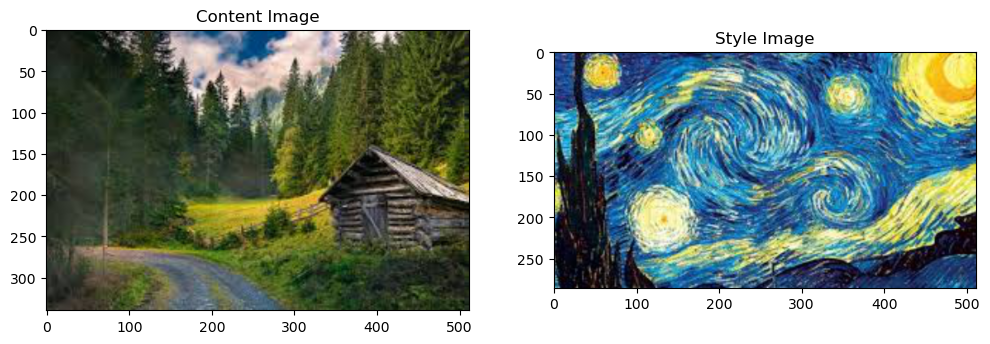

In [14]:
# Cargar las imágenes
content_image = load_img(content_path)
style_image = load_img(style_path)

# Mostrar las imágenes
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

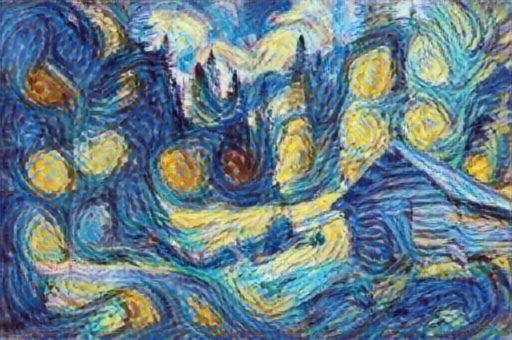

In [15]:
# Cargar el modelo de TensorFlow Hub para transferencia de estilo
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Aplicar la transferencia de estilo entre las imágenes de contenido y estilo
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]
tensor_to_image(stylized_image)

## EJERCICIO 6

Crea un modelo sencillo que aplique un filtro personalizado a una imagen de contenido mediante una capa convolucional es un buen ejercicio para entender cómo funcionan las convoluciones en el procesamiento de imágenes.

Carga una imagen desde archivo preparala para se procesada por la red:
* Cargar la imagen (tf.keras.preprocessing.image.load_im)
* Convertir la imagen a un tensor de NumPy y redimensionarla:
    * tf.keras.preprocessing.image.img_to_array
    * tf.image.resize
* Añadir una dimensión de batch al tensor de la imagen (np.expand_dims)


In [4]:
# Cargar la imagen
img_path = './images/tortuga.jpeg'  
img = tf.keras.preprocessing.image.load_img(img_path)

# Convertir la imagen a un tensor y redimensionarla
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_resized = tf.image.resize(img_array, (256, 256))

# Añadir una dimensión de batch
img_resized = np.expand_dims(img_resized, axis=0)
img_resized.shape

(1, 256, 256, 3)

Define un filtro personalizado para aplicar a la imagen. Los filtros son matrices pequeñas que modifican los píxeles de la imagen al aplicar la convolución.

Por ejemplo aquí tienes un filtro de bordes:

```python
filtro = np.array([
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]
], dtype=np.float32)
```
El filtro debe tener forma (altura, anchura, canales_entrada, canales_salida) (usa reshape)

In [5]:
# Definir un filtro
filtro = np.array([
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]
], dtype=np.float32)

# Asegurarnos de que el filtro tiene la forma correcta
filtro = filtro.reshape((3, 3, 3, 1)) 

Crea un modelo secuencial en Keras con una única capa convolucional que utilice tu filtro personalizado.

In [6]:
# Definir el modelo con una capa convolucional que aplique el filtro
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=1, 
        kernel_size=(3, 3), 
        strides=(1, 1), 
        padding='same', 
        use_bias=False, 
        input_shape=(256, 256, 3)
    )
])

model.layers[0].set_weights([filtro])



In [7]:
output = model(img_resized)

Visualiza el resultado (muestra la imagen original y la imagen con el filtro y pon un título a cada imagen)

In [8]:
# Eliminamos la dimensión de batch
output_image = output.numpy().squeeze()

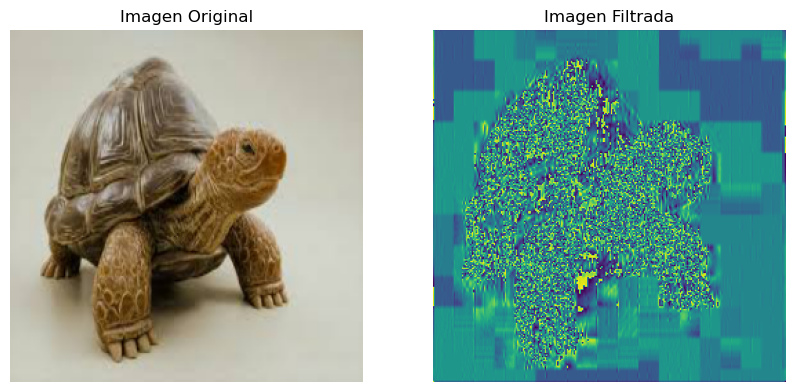

In [11]:
# Visualizar la imagen original y la imagen filtrada
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized.squeeze().astype(np.uint8))
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_image.astype(np.uint8))
plt.title("Imagen Filtrada")
plt.axis('off')

plt.show()


## EJERCICIO 7
Repite el ejercicio anterior con diferentes modelos y filtros:
* Prueba otro filtro (mostrar imagen original e imagen con filtro)
* Prueba con tres filtros a la vez (mostrar la imagen resultante de cada filtro)
* Prueba con tres filtros y dos capas convolucionales (mostrar imagen original e imagne con filtro)

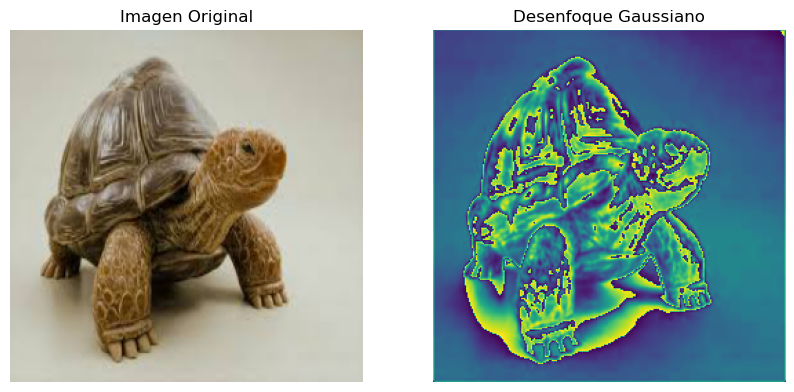

In [12]:
# Definir un filtro de desenfoque gaussiano
filtro_gaussiano = np.array([
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]],
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]],
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]]
], dtype=np.float32)

# Asegurarnos de que el filtro tiene la forma correcta
filtro_gaussiano = filtro_gaussiano.reshape((3, 3, 3, 1)) 

# Definir el modelo con el filtro gaussiano
model_gaussiano = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=1, 
        kernel_size=(3, 3), 
        strides=(1, 1), 
        padding='same', 
        use_bias=False, 
        input_shape=(256, 256, 3)
    )
])

model_gaussiano.layers[0].set_weights([filtro_gaussiano])

# Aplicar el filtro a la imagen de entrada
output_gaussiano = model_gaussiano(img_resized)

# Eliminamos la dimensión de batch
output_gaussiano_image = output_gaussiano.numpy().squeeze()

# Visualizar la imagen original y la imagen con el filtro de desenfoque
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized.squeeze().astype(np.uint8))
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_gaussiano_image.astype(np.uint8))
plt.title("Desenfoque Gaussiano")
plt.axis('off')

plt.show()

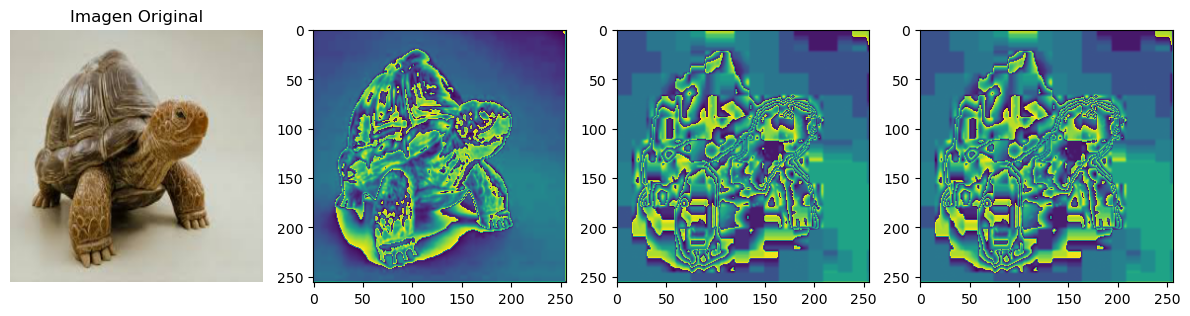

In [13]:
# Definir tres filtros diferentes
filtro1 = np.array([
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]],
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]],
    [[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]]
], dtype=np.float32).reshape((3, 3, 3, 1))

filtro2 = np.array([
     [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
], dtype=np.float32).reshape((3, 3, 3, 1))

filtro3 = np.array([
    [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
    [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
], dtype=np.float32).reshape((3, 3, 3, 1))

# Definir el modelo con tres filtros
model_tres_filtros = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=3, 
        kernel_size=(3, 3), 
        strides=(1, 1), 
        padding='same', 
        use_bias=False, 
        input_shape=(256, 256, 3)
    )
])

model_tres_filtros.layers[0].set_weights([np.concatenate([filtro1, filtro2, filtro3], axis=-1)])

# Aplicar los filtros a la imagen de entrada
output_tres_filtros = model_tres_filtros(img_resized)

# Eliminamos la dimensión de batch
output_tres_filtros_images = output_tres_filtros.numpy().squeeze()

# Visualizar la imagen original y las imágenes con los tres filtros
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_resized.squeeze().astype(np.uint8))
plt.title("Imagen Original")
plt.axis('off')

for i in range(3):
    plt.subplot(1, 4, i+2)
    plt.imshow(output_tres_filtros_images[:, :, i].astype(np.uint8))
    


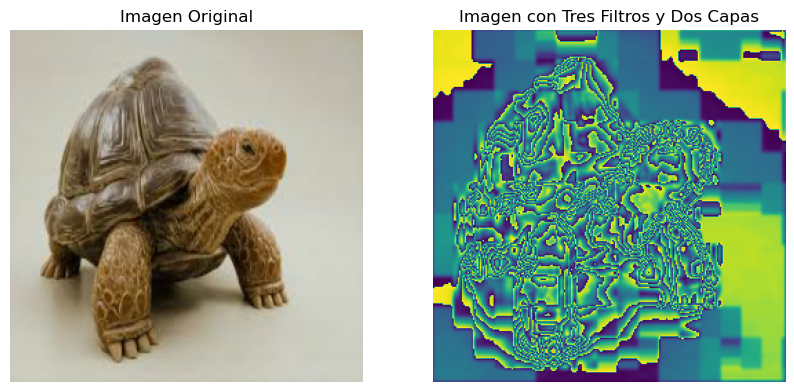

In [16]:
# Definir el modelo con dos capas convolucionales
model_dos_capas = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=3, 
        kernel_size=(3, 3), 
        strides=(1, 1), 
        padding='same', 
        use_bias=False, 
        input_shape=(256, 256, 3)
    ),
    tf.keras.layers.Conv2D(
        filters=1, 
        kernel_size=(3, 3), 
        strides=(1, 1), 
        padding='same', 
        use_bias=False, 
    )
])

model_dos_capas.layers[0].set_weights([np.concatenate([filtro1, filtro2, filtro3], axis=-1)])
model_dos_capas.layers[1].set_weights([filtro1]) 

# Aplicar las dos capas convolucionales
output_dos_capas = model_dos_capas(img_resized)

# Eliminamos la dimensión de batch
output_dos_capas_image = output_dos_capas.numpy().squeeze()

# Visualizar la imagen original y la imagen con los tres filtros aplicados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_resized.squeeze().astype(np.uint8))
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_dos_capas_image.astype(np.uint8))
plt.title("Imagen con Tres Filtros y Dos Capas")
plt.axis('off')

plt.show()
